In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots

Original Dr. Will Jupyter notebook
https://github.com/will-henney/lvm-turbulence/blob/main/lvm-tarantula-explore-122.ipynb

#  Data

In [3]:
#line        = r'H$\alpha$'
#lambda_rest = 6562.8
#line_id     = 'H'
#line_id2   = "6563"

In [4]:
#line        = r'[N II] $\lambda$6583'
#lambda_rest = 6583.45
#line_id     = 'NIIa'
#line_id2    = "6583" 

In [5]:
#line        = r'[O II] $\lambda$3726'
#lambda_rest = 3726.03 
#line_id     = 'OIIb'
#line_id2   = "3726"

In [6]:
#line        = r'[O II] $\lambda$3729'
#lambda_rest = 3728.80 
#line_id     = 'OIIa'
#line_id2   = "3729"

In [7]:
#line        = r'[O III]$\lambda$ 5007'
#lambda_rest = 5006.9
#line_id     = 'OIIIa'
#line_id2   = "5007"

In [8]:
#line        = r'[S II] $\lambda$6731'
#lambda_rest = 6730.8
#line_id     = 'SIIa'
#line_id2    = "6731" 

In [9]:
line        = r'[S III] $\lambda$9069'
lambda_rest = 9069.1
line_id     = 'SIIIb'
line_id2   = "9069"

In [10]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + line_id2 
name_id      =  inst_id + '-' + reg_id + '-' + line_id2 + '_rot'
print(name_file)
print(name_id)


LVM-30Dor-9069
LVM-30Dor-9069_rot


In [11]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [12]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [13]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [14]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
#ra0 = _line["RAdeg"].median()
#dec0 = _line["DEdeg"].median()
print(ra0, dec0)

84.675 -69.1


In [15]:
from astropy.coordinates import SkyCoord
import astropy.units as u

centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)

radio = 1652/2 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]


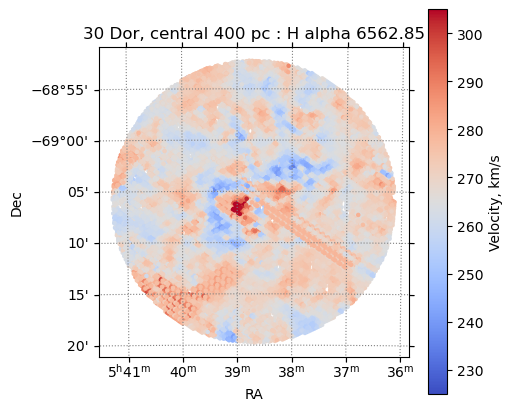

In [16]:
fig, ax = plt.subplots(
    figsize = (5,5),
    subplot_kw=dict(projection=wcs)
)

        
scat = ax.scatter(line_rad.RAdeg, 
           line_rad.DEdeg,
           s= 5,
           c = line_rad.V_mean,
           cmap="coolwarm",
           vmin=225,
           vmax=305,
           transform=ax.get_transform("world")
          )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"30 Dor, central 400 pc : H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")

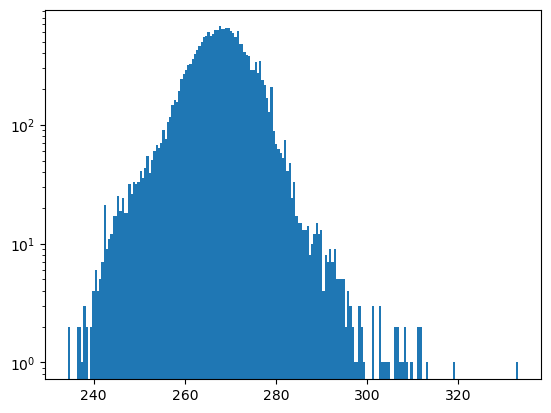

In [17]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [18]:
mu = line_rad["V_mean"].mean()
sigma = line_rad["V_mean"].std()
n = 3.0

#line_mask = line_rad[np.log10(line_rad["log_F"]) > 0.5]
#line_mask = line_rad[(line_rad["log_F"] > 1000) 
#     & (line_rad["V_mean"] > (mu - n*sigma)) & (line_rad["V_mean"] < (mu + n*sigma))]
mask = (line_rad["V_mean"] > 240) & (line_rad["V_mean"]<295) & (line_rad["log_F"] > 100) 

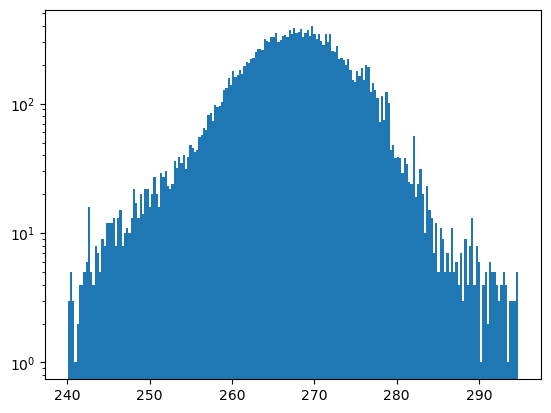

In [19]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"][mask] , bins=200)
ax.set_yscale("log")

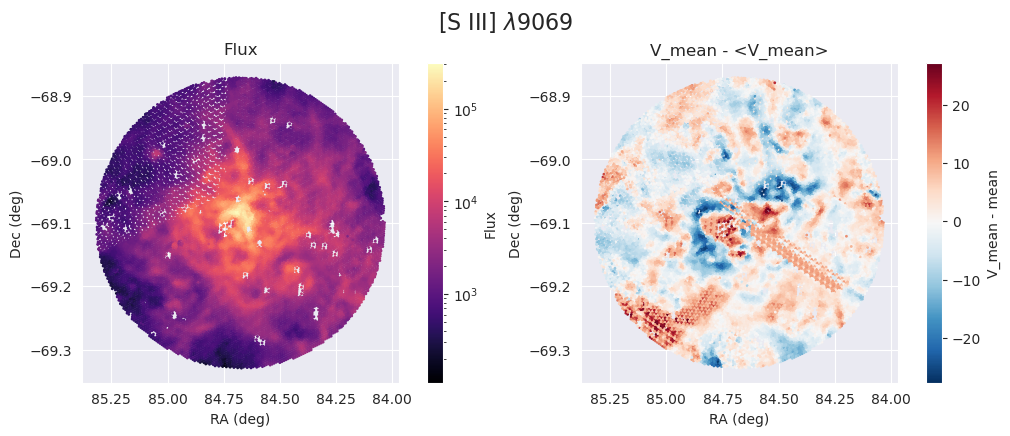

<Figure size 640x480 with 0 Axes>

In [20]:
fig, ax = list_maps_plots.plot_panels_log_title(line_rad[mask],
                                                 s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=line)
plt.show()
plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [21]:
df =  line_rad[mask]

In [22]:
df.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,20687.000000,20687.000000,20687.000000,20687.000000,20687.000000
mean,84.680629,-69.096162,267.704303,7739.631566,0.978133
std,0.320728,0.113378,7.110434,19685.526162,0.133289
min,84.032926,-69.329018,240.013500,110.205800,0.534600
25%,84.423709,-69.186293,263.589900,1250.218500,0.885700
50%,84.691953,-69.096040,267.917400,2725.155000,0.959800
75%,84.937576,-69.005254,272.083650,6289.113300,1.022600
max,85.317236,-68.870945,294.821800,310989.144300,2.000000


# Export Data

In [23]:
N = np.sqrt((df.RAdeg.max()-df.RAdeg.min())*(df.DEdeg.max()-df.DEdeg.min())) * pc * 3600
sig       = df['V_mean'].std()

In [24]:
t         = Table.from_pandas(line_rad[mask].reset_index(drop=True))
table_hdu = fits.BinTableHDU(t, name=name_id)

In [25]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]= (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [26]:
hdul = fits.HDUList([primary, table_hdu])
hdul.writeto("fits_ready/" + name_id + ".fits", overwrite=True)

In [27]:
with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()

Filename: fits_ready/LVM-30Dor-9069_rot.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  LVM-30DOR-9069_ROT    1 BinTableHDU     19   20687R x 5C   [D, D, D, D, D]   
